In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_package')

from irc.manager import AgentManager

from auditoryforage.utils import plot_AF_episode

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialize a manager for rational agents

In [2]:
# from irc.manager import AgentManager
# defaults = {'env._target_': 'irc.examples.IdenticalBoxesEnv'}
# manager = AgentManager(defaults=defaults)

defaults = {
    'env._target_': 'auditoryforage.AF_env.AuditoryForaging'
}
manager = AgentManager(defaults=defaults)

Train and inspect a rational agent

Checkpoint (epoch 110) loaded.


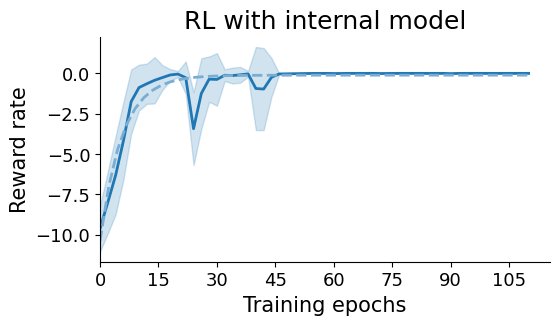

In [3]:
# agent, key = manager.train_agent() # using default environment parameter

# env_param = (0.2, 0.05, 0.8, 0.1, 10., -1.)
# agent, key = manager.train_agent(env_param=env_param, num_epochs=10)

# env_param = [-3.0, 200.0, .08, .25, -5000, 0] #better set of parameters, need to adjust below grid accordingly
env_param = [-3.0, 16.0, 30, 14, -50, 0]
num_epochs = 110
agent, key = manager.train_agent(env_param = env_param, num_epochs=num_epochs)
agent, fig = manager.inspect_agent(key, figsize=(5, 2.5))

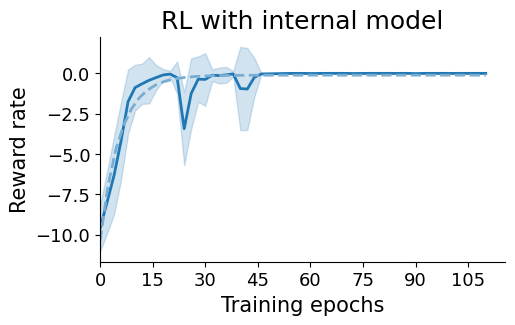

In [4]:
agent, fig = manager.inspect_agent(key)

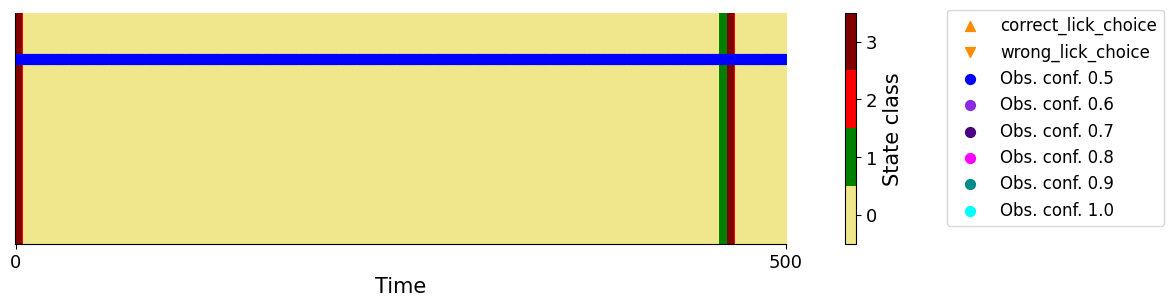

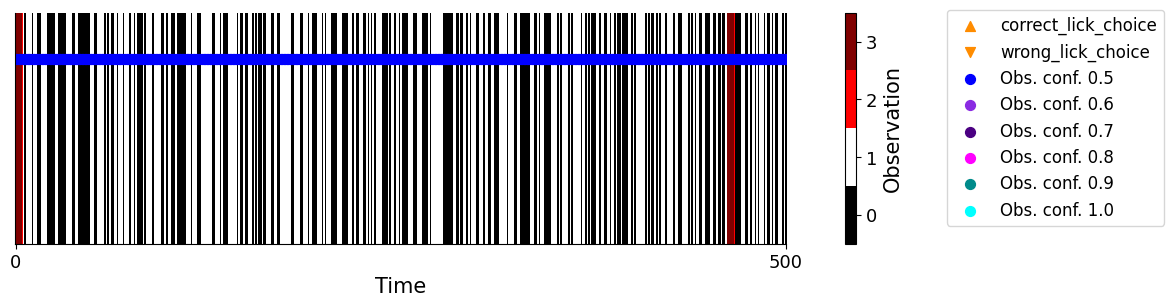

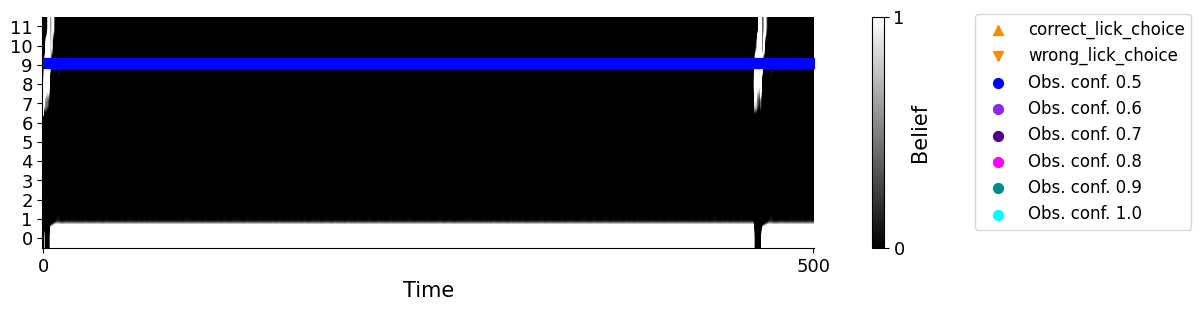

In [5]:
# if `env` is not specified, agent interacts with its assumed environment
episode = agent.run_one_episode()

# run the agent in an environment different from assumption
# env = IdenticalBoxesEnv()
from auditoryforage.AF_env import AuditoryForaging
env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, max_steps=500)
fig = plot_AF_episode(episode, env, agent)

env.spec

Sweep over a grid of environment parameters

In [6]:
# param_grid = [
#     [0.1, 0.2, 0.3],    # p_appear
#     [],                 # p_vanish
#     [0.6, 0.8],         # p_cue
#     [],                 # lambda_center
#     [10., 5.],          # r_food
#     [],                 # r_move
# ]
param_grid = [
    [-3.0], # lick_cost
    [16.0], # food_reward
    [20, 25, 30, 35, 40], # attention_cost_coeff
    [6, 10, 14, 18, 22], # attention_cost_temp
    [-50],
    [0]
]
seeds = range(2)
manager.train_agents_on_grid(param_grid=param_grid, seeds=seeds, num_epochs=20)


0 works processed.
All works are processed or being processed.


Monitor the training progress of agents

In [7]:
# Needs change in documentation for below line
# report = manager.overview_agents_on_grid(env_param_grid=env_param_grid, seeds=seeds)
report = manager.overview_agents_on_grid(env_param_grid=param_grid, seeds=seeds)

AttributeError: 'AgentManager' object has no attribute 'overview_agents_on_grid'

Compute likelihood of episode data

In [8]:
# beliefs, logps = agent.compute_likelihoods(observations, actions)
beliefs, logps = agent.compute_likelihoods(episode['observations'], episode['actions'])

Distill a single agent from a family of agents

In [9]:
d_agent, train_stats = manager.distill_agents_on_grid(param_grid, save_path='wukong.pt')

Train Policy Net   100%|##################################################| 60/60 [02:39<00:00,  2.66s/epoch]


Inferring environment parameter with distilled agent (true env param in below example is (-3.0, 16.0, 30, 14, -50, 0))

In [11]:
d_agent.sga_inference(episode['observations'], episode['actions'], (-3.0, 16.0, 30, 14, -50, 0))
print(d_agent.model.get_param())

Use default discount parameter gamma=0.99
Use default curiosity parameter ent_coef=0.01
[ -3.6695745  17.490683   31.233524   11.461159  -50.549564    1.0775626]


In [13]:
d_agent.sga_inference(episode['observations'], episode['actions'], (-3.0, 1.0, 30, 14, -50, 0))
print(d_agent.model.get_param())

Use default discount parameter gamma=0.99
Use default curiosity parameter ent_coef=0.01
[ -3.827972    3.5895422  33.00671     8.608377  -51.18372     2.0337927]
